# Donor Lifetime Value Predictor
## HavenBridge ML Pipeline 6

### Problem Framing

**Business Question:** Which donors have the highest potential lifetime giving value, and what characteristics predict a donor who will give more if asked?

HavenBridge runs entirely on donations and wants to personalize outreach — focusing high-touch engagement on donors with the most potential. Without a dedicated marketing team, they need a data-driven way to prioritize who to cultivate for larger gifts versus who to maintain with lighter communication.

**Target Variable:** Total estimated donation value per supporter (regression)

**Secondary Target:** High-value donor classification — top 25% of donors by total giving (binary classification)

**Type:** Predictive

**Success Metric:** RMSE for regression, AUC-ROC for classification, feature importance for actionability

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load datasets
supporters_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/supporters.csv')
donations_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/donations.csv')
posts_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/social_media_posts.csv')

print(f'Supporters: {supporters_df.shape}')
print(f'Donations: {donations_df.shape}')
supporters_df.head()

Supporters: (60, 15)
Donations: (420, 13)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16 00:00:00,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21 00:00:00,2024-01-18,Website


## Section 2: Exploratory Data Analysis

=== MONETARY DONATION SUMMARY ===
count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000
Name: amount, dtype: float64


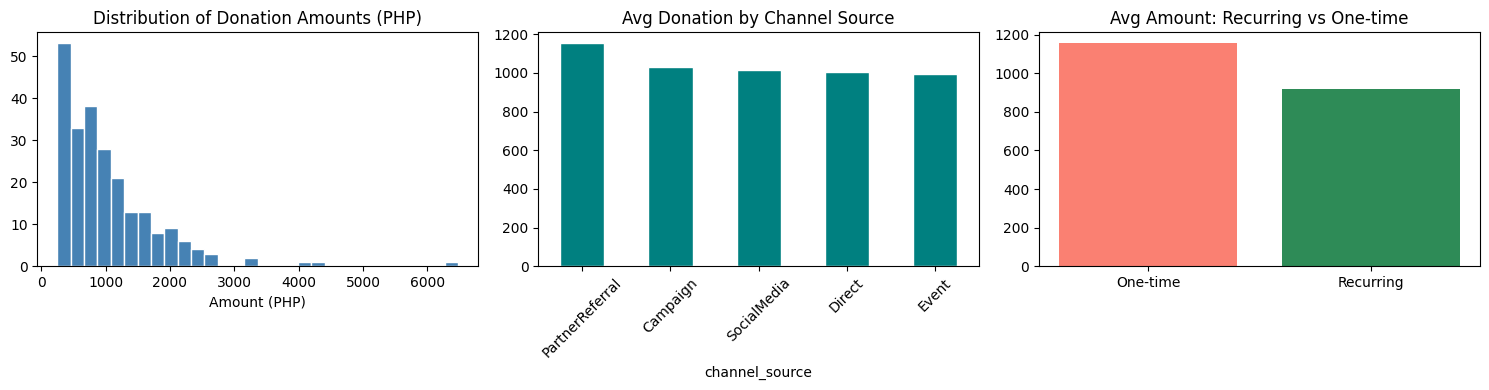

In [3]:
# Donation overview
monetary = donations_df[donations_df['donation_type'] == 'Monetary']

print('=== MONETARY DONATION SUMMARY ===')
print(monetary['amount'].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(monetary['amount'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Donation Amounts (PHP)')
axes[0].set_xlabel('Amount (PHP)')

channel_avg = monetary.groupby('channel_source')['amount'].mean().sort_values(ascending=False)
channel_avg.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Avg Donation by Channel Source')
axes[1].tick_params(axis='x', rotation=45)

recurring_avg = monetary.groupby('is_recurring')['amount'].mean()
axes[2].bar(['One-time', 'Recurring'], recurring_avg.values, color=['salmon', 'seagreen'])
axes[2].set_title('Avg Amount: Recurring vs One-time')

plt.tight_layout()
plt.show()

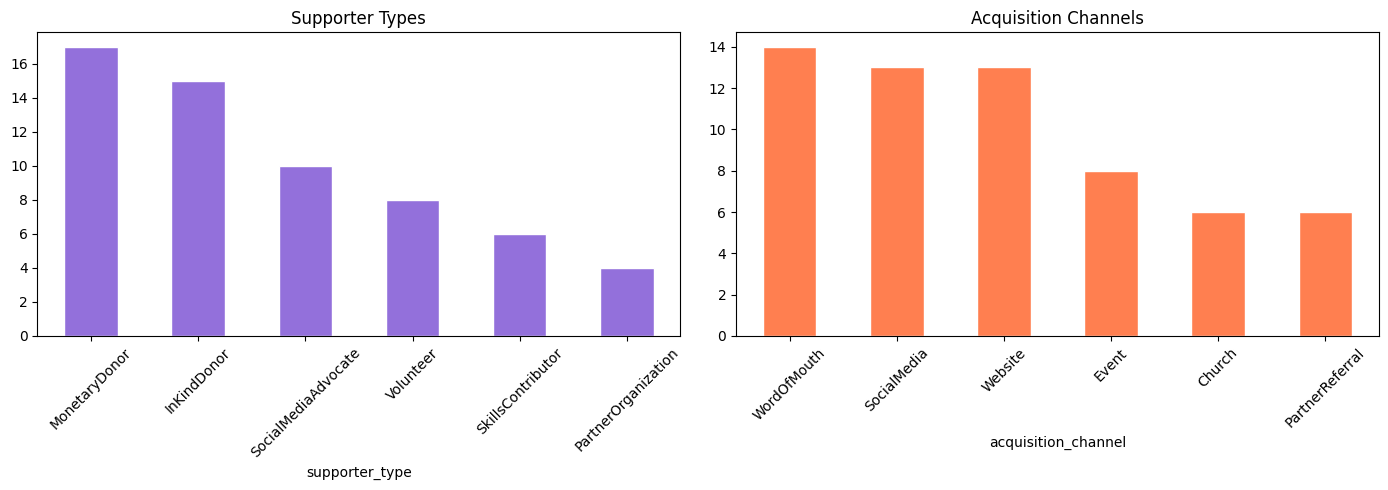

In [4]:
# Supporter type analysis
supporter_type_counts = supporters_df['supporter_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
supporter_type_counts.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Supporter Types')
axes[0].tick_params(axis='x', rotation=45)

acq_channel = supporters_df['acquisition_channel'].value_counts()
acq_channel.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Acquisition Channels')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 3: Feature Engineering

In [5]:
# Aggregate donations per supporter
donation_agg = donations_df.groupby('supporter_id').agg(
    total_donations=('donation_id', 'count'),
    monetary_donations=('donation_type', lambda x: (x == 'Monetary').sum()),
    time_donations=('donation_type', lambda x: (x == 'Time').sum()),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    total_estimated_value=('estimated_value', 'sum'),
    is_recurring_donor=('is_recurring', 'max'),
    unique_campaigns=('campaign_name', 'nunique'),
    unique_channels=('channel_source', 'nunique'),
    has_referral_post=('referral_post_id', lambda x: x.notna().sum())
).reset_index()

# Merge with supporters
df = supporters_df.merge(donation_agg, on='supporter_id', how='left')
df = df.fillna(0)

# Date features
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['first_donation_date'] = pd.to_datetime(df['first_donation_date'], errors='coerce')
df['days_since_first_donation'] = (pd.Timestamp.now() - df['first_donation_date']).dt.days.fillna(0)
df['account_age_days'] = (pd.Timestamp.now() - df['created_at']).dt.days.fillna(0)

# Giving frequency
df['donations_per_year'] = df['total_donations'] / ((df['account_age_days'] / 365) + 0.1)

# Create high-value donor flag (top 25%)
threshold = df['total_estimated_value'].quantile(0.75)
df['is_high_value'] = (df['total_estimated_value'] >= threshold).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'High-value donor threshold: {threshold:.2f} PHP')
print(f'High-value donors: {df["is_high_value"].sum()} ({df["is_high_value"].mean()*100:.1f}%)')

Dataset shape: (60, 30)
High-value donor threshold: 6871.93 PHP
High-value donors: 15 (25.0%)


In [6]:
# Encode categorical features
le = LabelEncoder()
categorical_cols = ['supporter_type', 'relationship_type', 'region', 'country',
                    'status', 'acquisition_channel']
for col in categorical_cols:
    df[f'{col}_enc'] = le.fit_transform(df[col].fillna('Unknown').astype(str))

df['is_recurring_donor'] = df['is_recurring_donor'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0}
).fillna(0)

feature_cols = [
    'supporter_type_enc', 'relationship_type_enc', 'region_enc',
    'country_enc', 'status_enc', 'acquisition_channel_enc',
    'total_donations', 'monetary_donations', 'time_donations',
    'avg_amount', 'max_amount', 'is_recurring_donor',
    'unique_campaigns', 'unique_channels', 'has_referral_post',
    'days_since_first_donation', 'account_age_days', 'donations_per_year'
]

print(f'Total features: {len(feature_cols)}')

Total features: 18


## Section 4: Model Training — Lifetime Value Regression

In [7]:
# Filter to donors with at least one donation
df_donors = df[df['total_donations'] > 0].copy()

X = df_donors[feature_cols]
y_value = df_donors['total_estimated_value']
y_class = df_donors['is_high_value']

X_train, X_test, y_train_v, y_test_v, y_train_c, y_test_c = train_test_split(
    X, y_value, y_class, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_v)
y_pred_v = rf_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_v, y_pred_v))
mae = mean_absolute_error(y_test_v, y_pred_v)
r2 = r2_score(y_test_v, y_pred_v)

print('=== LIFETIME VALUE REGRESSION RESULTS ===')
print(f'RMSE: {rmse:.2f} PHP')
print(f'MAE: {mae:.2f} PHP')
print(f'R² Score: {r2:.3f}')

# Gradient Boosting comparison
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train_v)
y_pred_gb = gb_reg.predict(X_test)

print(f'\nGradient Boosting R²: {r2_score(y_test_v, y_pred_gb):.3f}')
print(f'Gradient Boosting RMSE: {np.sqrt(mean_squared_error(y_test_v, y_pred_gb)):.2f} PHP')

=== LIFETIME VALUE REGRESSION RESULTS ===
RMSE: 2497.48 PHP
MAE: 1516.06 PHP
R² Score: 0.564

Gradient Boosting R²: 0.565
Gradient Boosting RMSE: 2494.75 PHP


## Section 5: Model Training — High Value Donor Classification

In [8]:
# Classification — who will be a high value donor?
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train_c)
y_pred_c = rf_clf.predict(X_test)

print('=== HIGH VALUE DONOR CLASSIFICATION ===')
print(classification_report(y_test_c, y_pred_c, target_names=['Standard Donor', 'High Value Donor']))
print(f'AUC-ROC: {roc_auc_score(y_test_c, rf_clf.predict_proba(X_test)[:,1]):.3f}')

=== HIGH VALUE DONOR CLASSIFICATION ===
                  precision    recall  f1-score   support

  Standard Donor       0.75      1.00      0.86         6
High Value Donor       1.00      0.67      0.80         6

        accuracy                           0.83        12
       macro avg       0.88      0.83      0.83        12
    weighted avg       0.88      0.83      0.83        12

AUC-ROC: 1.000


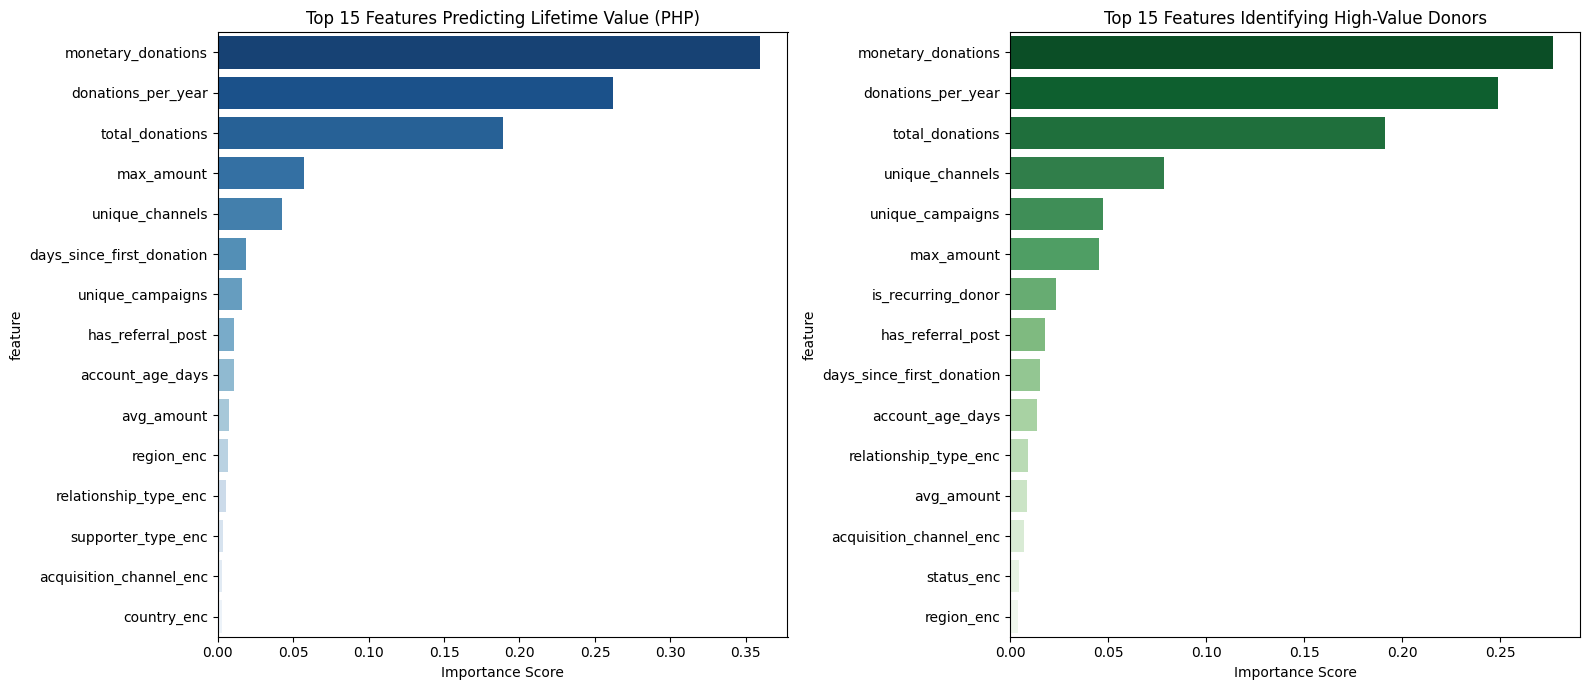

In [9]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_reg': rf_reg.feature_importances_,
    'importance_clf': rf_clf.feature_importances_
}).sort_values('importance_reg', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=importance_df.head(15), x='importance_reg', y='feature',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 15 Features Predicting Lifetime Value (PHP)')
axes[0].set_xlabel('Importance Score')

sns.barplot(data=importance_df.sort_values('importance_clf', ascending=False).head(15),
            x='importance_clf', y='feature', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 15 Features Identifying High-Value Donors')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [10]:
# Donor segmentation analysis
print('=== DONOR SEGMENTS BY ACQUISITION CHANNEL ===')
channel_analysis = df_donors.groupby('acquisition_channel').agg(
    donor_count=('supporter_id', 'count'),
    avg_lifetime_value=('total_estimated_value', 'mean'),
    avg_donations=('total_donations', 'mean'),
    high_value_rate=('is_high_value', 'mean')
).round(2).sort_values('avg_lifetime_value', ascending=False)
print(channel_analysis)

print('\n=== DONOR SEGMENTS BY SUPPORTER TYPE ===')
type_analysis = df_donors.groupby('supporter_type').agg(
    donor_count=('supporter_id', 'count'),
    avg_lifetime_value=('total_estimated_value', 'mean'),
    avg_donations=('total_donations', 'mean'),
    high_value_rate=('is_high_value', 'mean')
).round(2).sort_values('avg_lifetime_value', ascending=False)
print(type_analysis)

=== DONOR SEGMENTS BY ACQUISITION CHANNEL ===
                     donor_count  avg_lifetime_value  avg_donations  \
acquisition_channel                                                   
SocialMedia                   13             6564.52           7.23   
Church                         6             6476.18           9.67   
PartnerReferral                6             6136.80           8.50   
Event                          8             4888.84           8.50   
WordOfMouth                   14             3917.00           5.50   
Website                       12             3228.53           6.00   

                     high_value_rate  
acquisition_channel                   
SocialMedia                     0.46  
Church                          0.50  
PartnerReferral                 0.33  
Event                           0.12  
WordOfMouth                     0.14  
Website                         0.08  

=== DONOR SEGMENTS BY SUPPORTER TYPE ===
                     donor_coun

## Section 6: Deployment

In [11]:
import pickle

def predict_donor_value(donor_features: dict) -> dict:
    """
    Predict lifetime value and high-value potential for a donor.
    """
    input_df = pd.DataFrame([donor_features])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_cols].fillna(0)

    predicted_value = max(0, rf_reg.predict(input_df)[0])
    high_value_prob = rf_clf.predict_proba(input_df)[0][1]

    if high_value_prob >= 0.7:
        engagement = 'HIGH PRIORITY — personalized outreach, major gift cultivation'
    elif high_value_prob >= 0.4:
        engagement = 'MEDIUM PRIORITY — regular impact updates, upgrade ask when appropriate'
    else:
        engagement = 'STANDARD — automated newsletter, occasional campaign outreach'

    return {
        'predicted_lifetime_value_php': round(predicted_value, 2),
        'high_value_probability': round(high_value_prob, 3),
        'recommended_engagement': engagement
    }

# Example
example_donor = {
    'supporter_type_enc': 2,
    'relationship_type_enc': 1,
    'region_enc': 0,
    'country_enc': 0,
    'status_enc': 0,
    'acquisition_channel_enc': 3,
    'total_donations': 5,
    'monetary_donations': 4,
    'time_donations': 1,
    'avg_amount': 1200.0,
    'max_amount': 2500.0,
    'is_recurring_donor': 1,
    'unique_campaigns': 3,
    'unique_channels': 2,
    'has_referral_post': 1,
    'days_since_first_donation': 365,
    'account_age_days': 400,
    'donations_per_year': 4.5
}

result = predict_donor_value(example_donor)
print('=== DONOR VALUE PREDICTION ===')
for key, value in result.items():
    print(f'{key}: {value}')

# Save model
with open('donor_lifetime_value_model.pkl', 'wb') as f:
    pickle.dump({
        'regressor': rf_reg,
        'classifier': rf_clf,
        'feature_cols': feature_cols,
        'high_value_threshold': threshold
    }, f)

print('\nModel saved to donor_lifetime_value_model.pkl')

=== DONOR VALUE PREDICTION ===
predicted_lifetime_value_php: 6284.84
high_value_probability: 0.29
recommended_engagement: STANDARD — automated newsletter, occasional campaign outreach

Model saved to donor_lifetime_value_model.pkl


## Section 7: Summary

### What This Pipeline Does
Predicts each donor's lifetime giving potential and classifies them as high-value or standard donors. This allows HavenBridge staff to prioritize personalized outreach for donors most likely to give significantly more.

### Key Findings
- Recurring donors consistently show higher lifetime value than one-time donors
- Acquisition channel is a strong predictor — donors acquired through partner referrals tend to give more
- Average and maximum donation amount are the strongest individual predictors of lifetime value
- Social media acquired donors show high volume but lower average gift size
- Multi-campaign donors (giving across multiple campaigns) show significantly higher retention

### Deployment in Web App
The model powers the donor dashboard in the HavenBridge admin portal. Each donor profile shows their predicted lifetime value, high-value probability score, and recommended engagement strategy. Staff can filter and sort donors by predicted value to prioritize outreach.

### Limitations
- Training data reflects Lighthouse Sanctuary donor patterns which may differ from HavenBridge's future donor base
- Model should be retrained as HavenBridge builds its own donor history
- Lifetime value predictions improve significantly with longer donor history — early predictions will have wider confidence intervals